# 01 — Transformações e preservação dos rótulos

Base: [Yang et al., v2 (2023)](https://arxiv.org/abs/2204.08610v2), §§2.1–2.3 e Figura 1; [Buslaev et al., v1 (2018)](https://arxiv.org/abs/1809.06839v1), §II e Figuras 1–4. Os PDFs utilizados estão em `../articles/`.

**Objetivo:** verificar os mecanismos de transformações geométricas, fotométricas, apagamento e mistura. A imagem sintética tem máscara e caixa conhecidas; assim, podemos verificar os rótulos exatamente. Isso reproduz mecanismos, não as fotografias nem as métricas originais.

Execute as células em ordem. Dependências: `uv sync --group seminar3`. Não requer download de dados.

In [1]:
from pathlib import Path
import os
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'
import csv
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'seminar_3/articles').is_dir())
SEMINAR = ROOT / 'seminar_3'
OUT = SEMINAR / 'data/outputs'
PROCESSED = SEMINAR / 'data/processed'
OUT.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

def save_csv(path, rows):
    with path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/.venv/lib/python3.13/site-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


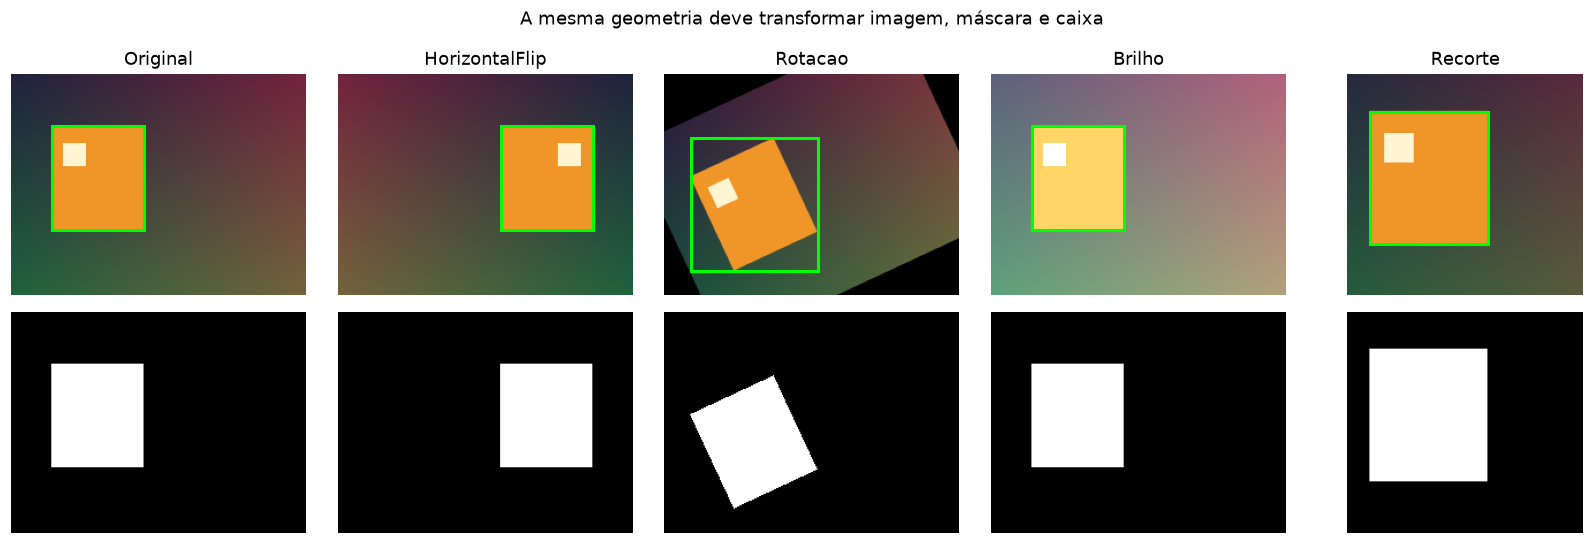

In [2]:
import albumentations as A
import cv2
from matplotlib.patches import Rectangle

# Imagem RGB assimétrica; classe 1 = objeto retangular.
y, x = np.mgrid[:192, :256]
image = np.stack((30 + x // 3, 35 + y // 3, np.full_like(x, 60)), axis=-1).astype(np.uint8)
mask = np.zeros((192, 256), dtype=np.uint8)
mask[45:135, 35:115] = 1
image[mask == 1] = [240, 150, 40]
image[60:80, 45:65] = [255, 245, 210]
box = [35, 45, 115, 135]  # Pascal VOC: limites superiores exclusivos neste exemplo.
Image.fromarray(image).save(OUT / 'original.png')
Image.fromarray(mask * 255).save(OUT / 'mask_original.png')

transforms = {
    'Original': A.NoOp(p=1),
    'HorizontalFlip': A.HorizontalFlip(p=1),
    'Rotacao': A.Affine(rotate=(25, 25), border_mode=cv2.BORDER_CONSTANT, p=1),
    'Brilho': A.RandomBrightnessContrast(brightness_limit=(0.25, 0.25), contrast_limit=0, p=1),
    'Recorte': A.Crop(x_min=20, y_min=20, x_max=180, y_max=170, p=1),
}
results = {}
fig, axes = plt.subplots(2, len(transforms), figsize=(15, 5))
for col, (name, transform) in enumerate(transforms.items()):
    pipeline = A.Compose([transform], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']), seed=42)
    result = pipeline(image=image, mask=mask, bboxes=[box], labels=[1])
    results[name] = result
    axes[0, col].imshow(result['image'])
    for x1, y1, x2, y2 in result['bboxes']:
        axes[0, col].add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='lime', lw=2))
    axes[1, col].imshow(result['mask'], cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(name)
    for ax in axes[:, col]: ax.axis('off')
    Image.fromarray(result['image']).save(OUT / f'{name}.png')
    Image.fromarray(result['mask'] * 255).save(OUT / f'mask_{name}.png')
fig.suptitle('A mesma geometria deve transformar imagem, máscara e caixa')
fig.tight_layout()
fig.savefig(OUT / 'transformacoes.png', bbox_inches='tight')
plt.show()

## Verificações que podem falhar
O flip preserva a área e é reversível. O brilho preserva a máscara. Interpolação de máscaras deve preservar os IDs das classes. Uma caixa girada é um retângulo envolvente; não é a máscara exata do objeto.

In [3]:
flipped = results['HorizontalFlip']
assert np.array_equal(flipped['mask'], mask[:, ::-1])
assert np.array_equal(flipped['image'][:, ::-1], image)
assert np.allclose(flipped['bboxes'][0], [256-115, 45, 256-35, 135])
assert np.array_equal(results['Brilho']['mask'], mask)
assert all(set(np.unique(r['mask'])) <= {0, 1} for r in results.values())

def iou(a, b):
    union = np.logical_or(a, b).sum()
    return np.logical_and(a, b).sum() / union if union else 1.0

correct = iou(flipped['mask'], mask[:, ::-1])
wrong = iou(mask, mask[:, ::-1])
assert correct == 1 and wrong == 0
print(f'IoU contra referência após flip: rótulo sincronizado={correct:.2f}; máscara esquecida={wrong:.2f}')

IoU contra referência após flip: rótulo sincronizado=1.00; máscara esquecida=0.00


## Cutout, Mixup e CutMix
Cutout apaga um trecho e mantém o rótulo original: só é válido se ainda houver evidência da classe.

Mixup combina **imagem e distribuição de classes**:
$\tilde x=\lambda x_a+(1-\lambda)x_b$, $\tilde y=\lambda y_a+(1-\lambda)y_b$.

CutMix troca um retângulo e usa $\lambda=1-\frac{\text{área efetivamente trocada}}{HW}$, considerando recorte nas bordas. A proporção de área é uma aproximação da contribuição semântica. Aqui são duas classes ilustrativas de formas, sem treinamento.

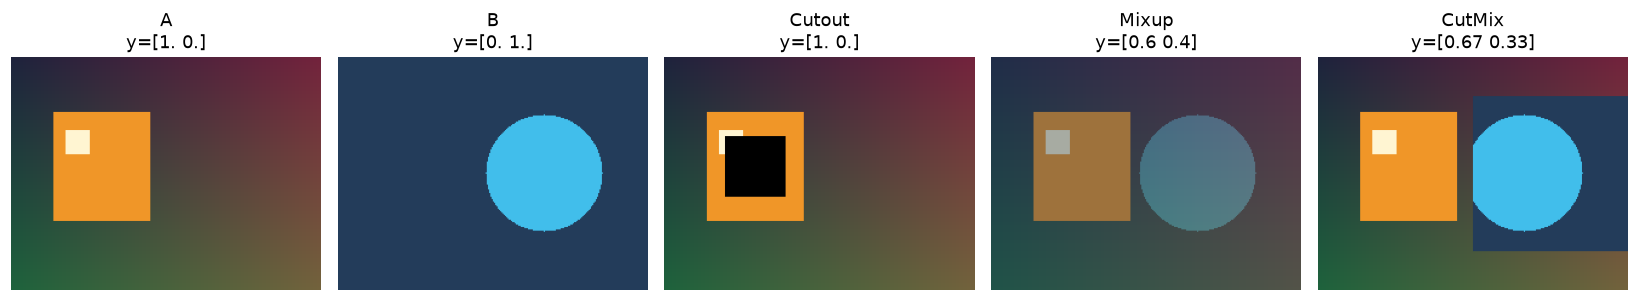

Verificações de geometria, máscaras e mistura: OK


In [4]:
other = np.full_like(image, [35, 60, 90])
circle = (x-170)**2 + (y-95)**2 <= 48**2
other[circle] = [65, 190, 235]
y_a, y_b = np.eye(2, dtype=np.float32)
lam = 0.6
mixup = np.rint(lam * image + (1-lam) * other).astype(np.uint8)
y_mixup = lam*y_a + (1-lam)*y_b
cutout = image.copy()
cutout[65:115, 50:100] = 0
cutmix = image.copy()
x1, y1, x2, y2 = 128, 32, 256, 160
cutmix[y1:y2, x1:x2] = other[y1:y2, x1:x2]
lam_cut = 1 - ((x2-x1)*(y2-y1)) / mask.size
mixed_label = lam_cut*y_a + (1-lam_cut)*y_b
assert np.isclose(y_mixup.sum(), 1) and np.isclose(mixed_label.sum(), 1)
assert np.array_equal(cutmix[y1:y2, x1:x2], other[y1:y2, x1:x2])
assert np.array_equal(cutmix[:, :x1], image[:, :x1])
assert np.isclose(lam_cut, 2/3)
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for ax, name, img, label in zip(axes, ['A', 'B', 'Cutout', 'Mixup', 'CutMix'],
                              [image, other, cutout, mixup, cutmix],
                              [y_a, y_b, y_a, y_mixup, mixed_label], strict=True):
    ax.imshow(img); ax.set_title(f'{name}\ny={np.round(label, 2)}'); ax.axis('off')
    Image.fromarray(img).save(OUT / f'mix_{name}.png')
fig.tight_layout()
fig.savefig(OUT / 'misturas.png', bbox_inches='tight')
plt.show()
print('Verificações de geometria, máscaras e mistura: OK')

## Para explicar no seminário
- A transformação precisa respeitar a semântica: um flip de uma cena pode ser válido, mas rotação de 180° de um dígito pode alterar sua classe.
- Aumentar dados não acrescenta novas observações independentes. Separe treino e teste **antes** de gerar variantes.
- A taxonomia inclui também busca automática, aumento no espaço de características e modelos generativos. Este roteiro implementa as famílias básicas; não treina GANs nem busca políticas.

A sincronização de caixas segue a [documentação oficial](https://albumentations.ai/docs/3-basic-usage/bounding-boxes-augmentations/). Usamos a versão fixa 2.0.8; o site também documenta versões posteriores.